In [22]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from functools import reduce 

In [14]:
df = pd.read_csv('../data/auf.csv')
df.head()


,x1,x2,x3,x4,x5,y
0,0.856817,0.213343,0.499305,0.636034,0.263721,36.652418
1,0.589961,0.887587,0.431929,0.059616,0.841818,397.258974
2,0.027474,0.386150,0.433366,0.835354,0.363672,11.548810
3,0.883609,0.820404,0.631249,0.987416,0.207131,24.320244
4,0.980357,0.611269,0.596272,0.661302,0.172421,77.805301


In [15]:
train,valid = train_test_split(df,test_size=0.3,random_state=2401)
train.reset_index(drop=True,inplace=True)
valid.reset_index(drop=True,inplace=True)
train.shape,valid.shape

((1399, 6), (600, 6))

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Prepare data
X_train = train.drop('y', axis=1)
y_train = train['y']
X_valid = valid.drop('y', axis=1)
y_valid = valid['y']

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_valid_pred = model.predict(X_valid)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
valid_mae = mean_absolute_error(y_valid, y_valid_pred)
train_r2 = r2_score(y_train, y_train_pred)
valid_r2 = r2_score(y_valid, y_valid_pred)

print(f"Training MAE: {train_mae:.4f}")
print(f"Validation MAE: {valid_mae:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Validation R²: {valid_r2:.4f}")

# Check for overfitting
if abs(train_mae - valid_mae) / valid_mae > 0.1:
    print("\nWarning: Model might be overfitting (significant difference between training and validation metrics)")
else:
    print("\nNo significant overfitting detected")


Training MAE: 1344267.3027
Validation MAE: 1026028.3130
Training R²: 0.0045
Validation R²: -1.8313



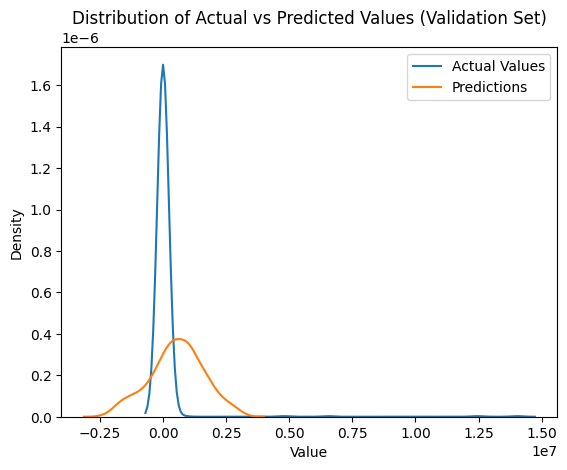

In [17]:
sns.kdeplot(y_valid, label='Actual Values')
sns.kdeplot(y_valid_pred, label='Predictions')
plt.title('Distribution of Actual vs Predicted Values (Validation Set)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [23]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV

# Scale the features
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_valid_scaled = X_scaler.transform(X_valid)

# Scale the target
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_valid_scaled = y_scaler.transform(y_valid.values.reshape(-1, 1)).ravel()

# Define parameter distributions for random search
param_distributions = {
    'hidden_layer_sizes': [(a,b,c) for a in range(2,10) for b in range(2,10) for c in range(2,10)],
    'activation': ['relu', 'tanh', 'logistic', 'identity'],
    'solver': ['adam', 'lbfgs', 'sgd'],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],  # regularization parameter
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [1000]
}

reduce(lambda x,y: x*y, map(len, param_distributions.values()))


221184

In [24]:
# Create base model
mlp = MLPRegressor(random_state=42)

# Perform random search
random_search = RandomizedSearchCV(
    mlp,
    param_distributions,
    n_iter=1000,  # number of parameter settings to try
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Fit the model
random_search.fit(X_train_scaled, y_train_scaled)

# Get best model
best_mlp = random_search.best_estimator_

# Make predictions
y_train_pred_scaled = best_mlp.predict(X_train_scaled)
y_valid_pred_scaled = best_mlp.predict(X_valid_scaled)

# Inverse transform predictions
y_train_pred_mlp = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_valid_pred_mlp = y_scaler.inverse_transform(y_valid_pred_scaled.reshape(-1, 1)).ravel()

# Calculate metrics
train_mae_mlp = mean_absolute_error(y_train, y_train_pred_mlp)
valid_mae_mlp = mean_absolute_error(y_valid, y_valid_pred_mlp)
train_r2_mlp = r2_score(y_train, y_train_pred_mlp)
valid_r2_mlp = r2_score(y_valid, y_valid_pred_mlp)

print("\nMLP Regressor Results:")
print(f"Best parameters: {random_search.best_params_}")
print(f"Training MAE: {train_mae_mlp:.4f}")
print(f"Validation MAE: {valid_mae_mlp:.4f}")
print(f"Training R²: {train_r2_mlp:.4f}")
print(f"Validation R²: {valid_r2_mlp:.4f}")


/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/neural_network/_base.py:172: RuntimeWarning: overflow encountered in square
  return ((y_true - y_pred)


MLP Regressor Results:
Best parameters: {'solver': 'sgd', 'max_iter': 1000, 'learning_rate_init': 0.1, 'learning_rate': 'constant', 'hidden_layer_sizes': (3, 6, 2), 'alpha': 0.001, 'activation': 'logistic'}
Training MAE: 544627.8272
Validation MAE: 151387.4918
Training R²: -0.0008
Validation R²: 0.0038


/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
110 fits failed out of a total of 5000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
110 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/josegustavofuentescabrera/Documents/anahuac/supreme-chainsaw/.venv/lib/python3.13/site-packages/sklearn/mode

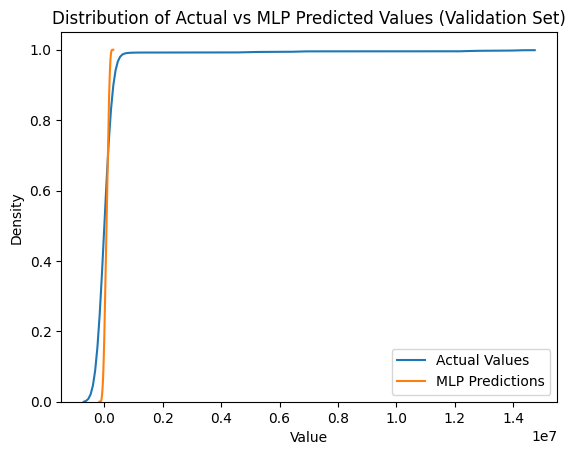

In [26]:
sns.kdeplot(y_valid, label='Actual Values',cumulative=True)
sns.kdeplot(y_valid_pred_mlp, label='MLP Predictions',cumulative=True)
plt.title('Distribution of Actual vs MLP Predicted Values (Validation Set)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

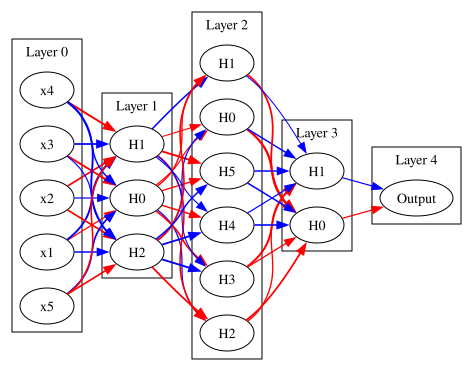

In [35]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display
import numpy as np

# Create a visualization of the neural network architecture
def visualize_mlp(mlp, feature_names):
    # Get the number of layers and their sizes
    n_layers = len(mlp.hidden_layer_sizes) + 2  # +2 for input and output layers
    layer_sizes = [X_train.shape[1]] + list(mlp.hidden_layer_sizes) + [1]
    
    # Create a new directed graph
    dot = graphviz.Digraph(comment='Neural Network Architecture')
    dot.attr(rankdir='LR')  # Left to right layout
    
    # Add nodes for each layer
    for i in range(n_layers):
        with dot.subgraph(name=f'cluster_{i}') as s:
            s.attr(label=f'Layer {i}')
            for j in range(layer_sizes[i]):
                node_id = f'L{i}_N{j}'
                if i == 0:  # Input layer
                    label = feature_names[j] if j < len(feature_names) else f'Input {j}'
                elif i == n_layers - 1:  # Output layer
                    label = 'Output'
                else:  # Hidden layers
                    label = f'H{j}'
                s.node(node_id, label)
    
    # Get weights from the MLP
    weights = best_mlp.coefs_
    
    # Add edges between layers with weights
    for i in range(n_layers - 1):
        for j in range(layer_sizes[i]):
            for k in range(layer_sizes[i + 1]):
                # Get weight value and normalize for visualization
                weight = weights[i][j, k]
                # Use absolute value of weight for thickness
                penwidth = str(1 + abs(weight) * 2)  # Scale weight for better visualization
                # Use weight sign for color
                color = 'blue' if weight > 0 else 'red'
                dot.edge(f'L{i}_N{j}', f'L{i+1}_N{k}', 
                        penwidth=penwidth, 
                        color=color)
    
    return dot

# Get feature names
feature_names = [f'x{i+1}' for i in range(X_train.shape[1])]

# Create and display the visualization
dot = visualize_mlp(best_mlp, feature_names)
display(dot)


In [36]:
best_mlp.coefs_

[array([[-0.12388236,  0.45340091,  0.22595276],
        [ 0.10006542, -0.34101295, -0.34958458],
        [-0.44010585,  0.36900306,  0.09488585],
        [ 0.20945844, -0.47632948,  0.46383325],
        [ 0.33376002, -0.28465246, -0.32387602]]),
 array([[-0.06053221, -0.19252767,  0.11403477, -0.32646251, -0.22487944,
         -0.15884794],
        [-0.03780767,  0.27285626, -0.27452308,  0.02634488,  0.05848753,
         -0.45976893],
        [ 0.10582858, -0.30530519, -0.3993026 ,  0.43905239,  0.40321002,
          0.25031995]]),
 array([[-0.64145331,  0.229004  ],
        [-0.3856865 ,  0.01470295],
        [-0.37017513, -0.16601193],
        [-0.14897351, -0.51467458],
        [ 0.2936905 ,  0.09789247],
        [ 0.25533098,  0.20915554]]),
 array([[-0.11472009],
        [ 0.08780082]])]

In [38]:
[x.shape for x in best_mlp.coefs_]

[(5, 3), (3, 6), (6, 2), (2, 1)]